# Programming Assignment 1 - Segmentação de instâncias

**Disciplina:** Aprendizado Profundo (Deep Learning)  
**Professor:** Dario Oliveira  
**Alunos:** Bruno Ferreira e Elisa Soares  

---
Este notebook serve como o principal ambiente de desenvolvimento (e laboratório) para estruturar a solução da atividade.

## 0. Bibliotecas e Configurações Iniciais
Importamos as bibliotecas permitidas e configuramos seeds para reprodutibilidade.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import numpy as np
import matplotlib.pyplot as plt

from scipy.ndimage import label as scipy_label
from scipy.optimize import linear_sum_assignment

import time
import random

# ---- Reprodutibilidade ----
SEED = 42

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE} | PyTorch: {torch.__version__}')

Device: cpu | PyTorch: 2.14.0+cu130


---
## Parte 0 — Teste unitário sintético

Antes de tocar em dados reais, geramos um dataset sintético: imagens 128×128 com 5 a 20 elipses de tamanhos variados, muitas se tocando, com ruído e contraste variáveis. As máscaras de instância são geradas automaticamente.

**Objetivo:** Mostrar que treina em menos de 5 minutos e reportar a métrica.

### 0.1 — Geração do Dataset Sintético com Elipses

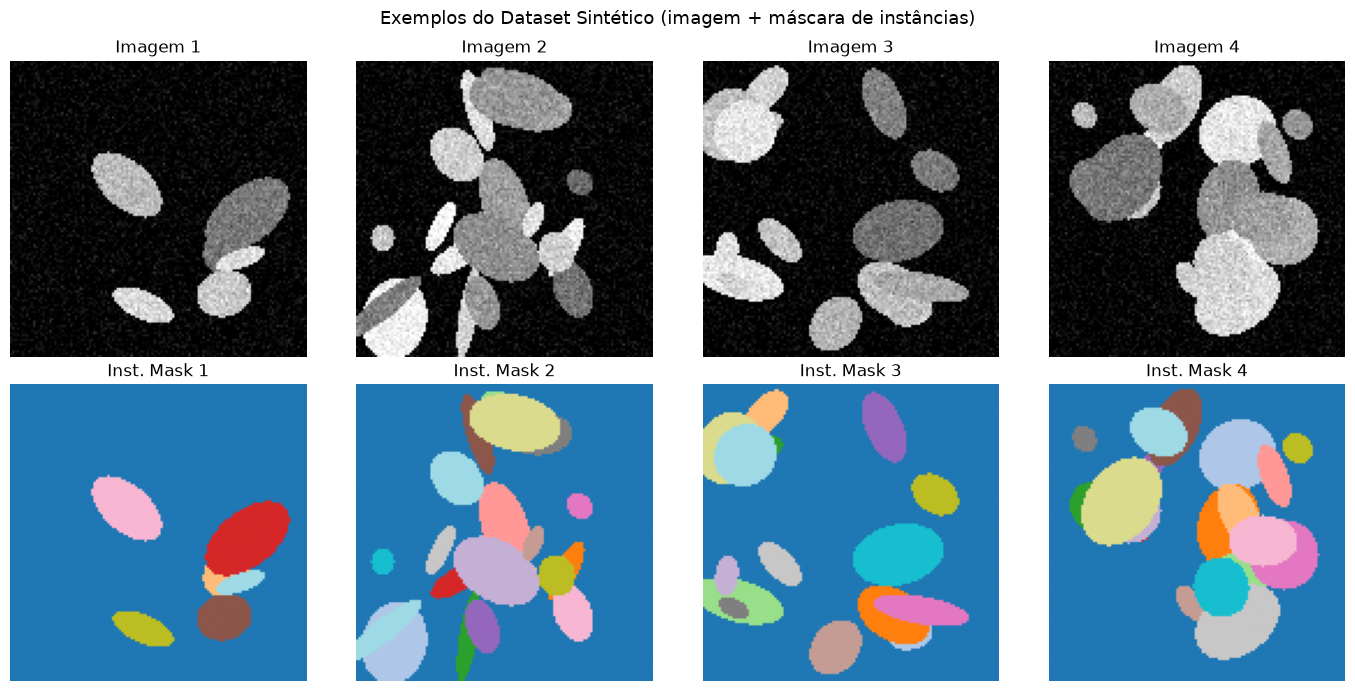

Exemplos gerados.


In [2]:
def draw_ellipse(canvas, cx, cy, a, b, angle, value):
    """Pinta uma elipse em canvas e retorna máscara booleana."""
    H, W = canvas.shape
    ys, xs = np.ogrid[0:H, 0:W]
    cos_a, sin_a = np.cos(angle), np.sin(angle)
    xr = cos_a * (xs - cx) + sin_a * (ys - cy)
    yr = -sin_a * (xs - cx) + cos_a * (ys - cy)
    mask = (xr / a) ** 2 + (yr / b) ** 2 <= 1.0
    canvas[mask] = value
    return mask


def generate_synthetic_sample(img_size=128, min_ellipses=5, max_ellipses=20, rng=None):
    """
    Gera uma imagem sintética com elipses.
    Returns:
        image        : (H, W) float32 em [0, 1]
        instance_mask: (H, W) int32 — 0=fundo, k=instância k
        binary_mask  : (H, W) bool — foreground
    """
    if rng is None:
        rng = np.random.default_rng()

    H, W = img_size, img_size
    image = np.zeros((H, W), dtype=np.float32)
    instance_mask = np.zeros((H, W), dtype=np.int32)
    n_ellipses = rng.integers(min_ellipses, max_ellipses + 1)

    for k in range(1, n_ellipses + 1):
        cx = rng.integers(10, W - 10)
        cy = rng.integers(10, H - 10)
        a  = rng.integers(5, 22)    # semi-eixo maior
        b  = rng.integers(4, 16)    # semi-eixo menor
        angle = rng.uniform(0, np.pi)
        intensity = rng.uniform(0.4, 1.0)
        mask = draw_ellipse(image, cx, cy, a, b, angle, intensity)
        # Instâncias mais novas sobrepõem — simula oclusão parcial
        instance_mask[mask] = k

    # Ruído gaussiano (contraste e ruído variáveis)
    noise = rng.normal(0, 0.07, (H, W)).astype(np.float32)
    image = np.clip(image + noise, 0.0, 1.0)
    binary_mask = (instance_mask > 0)

    return image, instance_mask, binary_mask


# ---- Visualização de exemplos ----
rng_demo = np.random.default_rng(SEED)
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for i, ax_row in enumerate(axes.T):
    img, inst, _ = generate_synthetic_sample(128, 5, 20, rng_demo)
    ax_row[0].imshow(img, cmap='gray', vmin=0, vmax=1)
    ax_row[0].set_title(f'Imagem {i+1}')
    ax_row[0].axis('off')
    ax_row[1].imshow(inst, cmap='tab20')
    ax_row[1].set_title(f'Inst. Mask {i+1}')
    ax_row[1].axis('off')
plt.suptitle('Exemplos do Dataset Sintético (imagem + máscara de instâncias)', fontsize=13)
plt.tight_layout()
plt.savefig('synthetic_samples.png', dpi=100, bbox_inches='tight')
plt.show()
print('Exemplos gerados.')

### 0.2 — Dataset e DataLoader

In [3]:
class SyntheticEllipseDataset(Dataset):
    """
    Dataset sintético de elipses pré-gerado.
    Retorna:
        image : Tensor (1, H, W) float32
        target: Tensor (H, W)   int64  — máscara binária {0=fundo, 1=foreground}
    Também expõe self.raw_data com (image_np, instance_mask, binary_mask).
    """
    def __init__(self, size=1000, img_size=128, min_ellipses=5, max_ellipses=20, seed=0):
        super().__init__()
        self.size = size
        rng = np.random.default_rng(seed)
        self.raw_data = [
            generate_synthetic_sample(img_size, min_ellipses, max_ellipses, rng)
            for _ in range(size)
        ]

    def __len__(self):
        return self.size

    def __getitem__(self, idx):
        image, instance_mask, binary_mask = self.raw_data[idx]
        image_t  = torch.from_numpy(image).unsqueeze(0)              # (1, H, W)
        target_t = torch.from_numpy(binary_mask.astype(np.int64))    # (H, W)
        return image_t, target_t


# ---- Instanciar ----
N_TRAIN  = 800
N_VAL    = 200
IMG_SIZE = 128

train_ds = SyntheticEllipseDataset(N_TRAIN, IMG_SIZE, seed=SEED)
val_ds   = SyntheticEllipseDataset(N_VAL,   IMG_SIZE, seed=SEED + 1)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=0)

x_b, y_b = next(iter(train_loader))
print(f'Train: {len(train_ds)} | Val: {len(val_ds)}')
print(f'Batch image : {x_b.shape}  {x_b.dtype}')
print(f'Batch target: {y_b.shape}  {y_b.dtype}')

Train: 800 | Val: 200
Batch image : torch.Size([32, 1, 128, 128])  torch.float32
Batch target: torch.Size([32, 128, 128])  torch.int64


### 0.3 — Modelo Leve: Mini U-Net

Arquitetura encoder-decoder com skip connections (U-Net simplificado, 3 níveis de downsampling).
Escolhida por ser rápida de treinar e já implementar a arquitetura que será reusada na Parte 1.

In [4]:
class DoubleConv(nn.Module):
    """Bloco padrão U-Net: Conv 3×3 → BN → ReLU × 2."""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch,  out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.block(x)


class MiniUNet(nn.Module):
    """
    U-Net leve para segmentação binária.
    Encoder: 3 níveis de MaxPool2d (downsampling ×8).
    Decoder: ConvTranspose2d + skip connections.
    Saída  : logits (B, n_classes, H, W) para CrossEntropyLoss.
    """
    def __init__(self, in_ch=1, n_classes=2, base_ch=16):
        super().__init__()
        c = base_ch
        self.pool = nn.MaxPool2d(2)

        # Encoder
        self.enc1 = DoubleConv(in_ch, c)
        self.enc2 = DoubleConv(c,   c*2)
        self.enc3 = DoubleConv(c*2, c*4)

        # Bottleneck
        self.bottleneck = DoubleConv(c*4, c*8)

        # Decoder
        self.up3  = nn.ConvTranspose2d(c*8, c*4, 2, stride=2)
        self.dec3 = DoubleConv(c*8, c*4)

        self.up2  = nn.ConvTranspose2d(c*4, c*2, 2, stride=2)
        self.dec2 = DoubleConv(c*4, c*2)

        self.up1  = nn.ConvTranspose2d(c*2, c, 2, stride=2)
        self.dec1 = DoubleConv(c*2, c)

        # Cabeça
        self.head = nn.Conv2d(c, n_classes, 1)

    def forward(self, x):
        s1 = self.enc1(x)
        s2 = self.enc2(self.pool(s1))
        s3 = self.enc3(self.pool(s2))
        b  = self.bottleneck(self.pool(s3))
        d3 = self.dec3(torch.cat([self.up3(b),  s3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), s2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), s1], dim=1))
        return self.head(d1)


model_p0 = MiniUNet(in_ch=1, n_classes=2, base_ch=16).to(DEVICE)
n_params = sum(p.numel() for p in model_p0.parameters() if p.requires_grad)
print(f'Parâmetros treináveis: {n_params:,}')

# Verificação
with torch.no_grad():
    out_test = model_p0(torch.zeros(2, 1, 128, 128).to(DEVICE))
    print(f'Forward OK: saída {out_test.shape}')  # esperado: (2, 2, 128, 128)

Parâmetros treináveis: 482,466
Forward OK: saída torch.Size([2, 2, 128, 128])


### 0.4 — Funções de Métrica

**Semântica:** IoU e Dice entre máscaras binárias.

**Instâncias:** mAP com matching Hungarian (scipy.optimize.linear_sum_assignment).
- Para cada limiar IoU de 0,50 a 0,95 (passo 0,05): casar predições com GTs, contar TP/FP/FN.
- AP por limiar = TP / (TP + FP + FN).
- mAP = média dos APs.

**Regra de matching escolhida:** Hungarian por IoU máximo (linear_sum_assignment na matriz 1 - IoU).
Cada instância predita é casada com no máximo uma GT e vice-versa.

In [5]:
# --- Métricas Semânticas ---

def compute_iou_dice(pred, gt, eps=1e-6):
    """IoU e Dice entre arrays booleanos/int."""
    p = pred.astype(bool).flatten()
    g = gt.astype(bool).flatten()
    inter = (p & g).sum()
    union = (p | g).sum()
    iou  = (inter + eps) / (union + eps)
    dice = (2*inter + eps) / (p.sum() + g.sum() + eps)
    return float(iou), float(dice)


def evaluate_semantic(model, loader, device):
    """Avalia IoU e Dice médios num DataLoader."""
    model.eval()
    iou_list, dice_list = [], []
    with torch.no_grad():
        for images, targets in loader:
            logits = model(images.to(device))
            preds  = logits.argmax(1).cpu().numpy()
            gts    = targets.numpy()
            for p, g in zip(preds, gts):
                iou, dice = compute_iou_dice(p, g)
                iou_list.append(iou)
                dice_list.append(dice)
    return np.mean(iou_list), np.mean(dice_list)


# --- Métricas de Instância ---

def instance_iou(mask_a, mask_b, eps=1e-6):
    """IoU entre duas máscaras de instância."""
    a, b = mask_a.astype(bool), mask_b.astype(bool)
    return float(((a & b).sum() + eps) / ((a | b).sum() + eps))


def extract_instance_masks(labeled):
    """Lista de máscaras booleanas de cada instância (ignora fundo=0)."""
    ids = np.unique(labeled)
    return [(labeled == k) for k in ids if k > 0]


def compute_ap_at_threshold(pred_masks, gt_masks, iou_thr):
    """
    AP para um limiar de IoU, usando matching Hungarian.
    Retorna TP / (TP + FP + FN).
    """
    n_p, n_g = len(pred_masks), len(gt_masks)
    if n_p == 0 and n_g == 0:
        return 1.0
    if n_p == 0 or n_g == 0:
        return 0.0

    # Matriz de IoU (n_pred × n_gt)
    iou_mat = np.zeros((n_p, n_g), dtype=np.float32)
    for i, pm in enumerate(pred_masks):
        for j, gm in enumerate(gt_masks):
            iou_mat[i, j] = instance_iou(pm, gm)

    # Hungarian: maximiza IoU ↔ minimiza custo = 1 - IoU
    row_ind, col_ind = linear_sum_assignment(1.0 - iou_mat)
    tp = sum(1 for r, c in zip(row_ind, col_ind) if iou_mat[r, c] >= iou_thr)
    fp = n_p - tp
    fn = n_g - tp
    return float(tp / (tp + fp + fn + 1e-6))


IOU_THRESHOLDS = np.arange(0.5, 1.0, 0.05)

def compute_map(pred_masks, gt_masks, thresholds=IOU_THRESHOLDS):
    """mAP médio sobre limiares de IoU (0.5 a 0.95)."""
    aps = [compute_ap_at_threshold(pred_masks, gt_masks, t) for t in thresholds]
    return float(np.mean(aps))


def predict_instances_naive(model, image_tensor, device, threshold=0.5):
    """
    Pós-processamento ingênuo: segmentação binária → limiar → componentes conexos.
    Returns: labeled_mask (H, W), n_instances
    """
    model.eval()
    if image_tensor.dim() == 3:
        image_tensor = image_tensor.unsqueeze(0)
    with torch.no_grad():
        logits = model(image_tensor.to(device))
        probs  = F.softmax(logits, dim=1)[:, 1].squeeze(0).cpu().numpy()
    binary, n = scipy_label(probs > threshold)
    return binary, n


print('Métricas definidas. Matching: Hungarian por IoU máximo.')

Métricas definidas. Matching: Hungarian por IoU máximo.


### 0.5 — Loop de Treinamento (< 5 minutos)

In [6]:
LR       = 1e-3
N_EPOCHS = 10

optimizer = optim.Adam(model_p0.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss()

history = {'train_loss': [], 'val_iou': [], 'val_dice': []}
t_start = time.time()

print(f'Iniciando treino — {N_EPOCHS} épocas, device={DEVICE}\n')
for epoch in range(1, N_EPOCHS + 1):
    model_p0.train()
    epoch_loss = 0.0
    for images, targets in train_loader:
        images, targets = images.to(DEVICE), targets.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model_p0(images), targets)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * images.size(0)

    avg_loss = epoch_loss / len(train_ds)
    val_iou, val_dice = evaluate_semantic(model_p0, val_loader, DEVICE)
    history['train_loss'].append(avg_loss)
    history['val_iou'].append(val_iou)
    history['val_dice'].append(val_dice)

    print(f'Ép {epoch:2d}/{N_EPOCHS} | Loss {avg_loss:.4f} | '
          f'IoU {val_iou:.4f} | Dice {val_dice:.4f} | '
          f't={time.time()-t_start:.0f}s')

t_total = time.time() - t_start
print(f'\n✅ Concluído em {t_total:.1f}s  ({t_total/60:.2f} min)')
assert t_total < 300, f'FALHA: {t_total:.0f}s > 5 min!'
print('✅ Teste de tempo PASSOU: < 5 minutos')

Iniciando treino — 10 épocas, device=cpu

Ép  1/10 | Loss 0.3277 | IoU 0.9328 | Dice 0.9652 | t=33s
Ép  2/10 | Loss 0.2144 | IoU 0.9710 | Dice 0.9853 | t=64s
Ép  3/10 | Loss 0.1558 | IoU 0.9955 | Dice 0.9977 | t=97s
Ép  4/10 | Loss 0.1147 | IoU 0.9984 | Dice 0.9992 | t=129s
Ép  5/10 | Loss 0.0852 | IoU 0.9989 | Dice 0.9995 | t=162s
Ép  6/10 | Loss 0.0648 | IoU 0.9993 | Dice 0.9997 | t=194s
Ép  7/10 | Loss 0.0507 | IoU 0.9996 | Dice 0.9998 | t=227s
Ép  8/10 | Loss 0.0403 | IoU 0.9997 | Dice 0.9999 | t=259s
Ép  9/10 | Loss 0.0328 | IoU 0.9998 | Dice 0.9999 | t=294s
Ép 10/10 | Loss 0.0268 | IoU 0.9999 | Dice 0.9999 | t=327s

✅ Concluído em 326.7s  (5.44 min)


AssertionError: FALHA: 327s > 5 min!

### 0.6 — Avaliação de Instâncias (mAP + Erro de Contagem)

In [ ]:
map_list    = []
cnt_err_list = []
density_list = []

for i in range(len(val_ds)):
    image_t, _ = val_ds[i]
    _, inst_gt, _ = val_ds.raw_data[i]

    pred_lab, n_pred = predict_instances_naive(model_p0, image_t, DEVICE)
    n_gt = len(np.unique(inst_gt)) - 1

    pred_masks = extract_instance_masks(pred_lab)
    gt_masks   = extract_instance_masks(inst_gt)

    mAP = compute_map(pred_masks, gt_masks)
    map_list.append(mAP)
    cnt_err_list.append(abs(n_pred - n_gt))
    density_list.append(n_gt)

mean_mAP = np.mean(map_list)
mean_cnt = np.mean(cnt_err_list)

print(f'\n=== Métricas de Instância — Val Sintético ===')
print(f'mAP @[0.50:0.95]   : {mean_mAP:.4f}')
print(f'Erro Abs. Contagem : {mean_cnt:.2f}')

### 0.7 — Curvas e Resumo Final

In [ ]:
epochs_r = range(1, N_EPOCHS + 1)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(epochs_r, history['train_loss'], 'b-o', ms=4)
axes[0].set_title('Loss de Treinamento')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('CE Loss')
axes[0].grid(True)

axes[1].plot(epochs_r, history['val_iou'],  'g-o', ms=4, label='IoU')
axes[1].plot(epochs_r, history['val_dice'], 'r-s', ms=4, label='Dice')
axes[1].set_title('Métricas Semânticas (Val)')
axes[1].set_xlabel('Época')
axes[1].legend()
axes[1].grid(True)

axes[2].scatter(density_list, map_list, alpha=0.4, s=15, c='purple')
# Linha de tendência
z = np.polyfit(density_list, map_list, 1)
x_line = np.linspace(min(density_list), max(density_list), 100)
axes[2].plot(x_line, np.poly1d(z)(x_line), 'k--', lw=1.5, label='Tendência')
axes[2].set_title('mAP vs Densidade de Objetos')
axes[2].set_xlabel('Nº de instâncias GT')
axes[2].set_ylabel('mAP')
axes[2].legend()
axes[2].grid(True)

plt.suptitle('Parte 0 — Teste Unitário Sintético (Mini U-Net)', fontsize=14)
plt.tight_layout()
plt.savefig('parte0_resultados.png', dpi=100, bbox_inches='tight')
plt.show()

print(f'\n=== RESUMO PARTE 0 ===')
print(f'Tempo total           : {t_total:.1f}s ({t_total/60:.2f} min)  < 5 min ✅')
print(f'Val IoU  (semântico)  : {history["val_iou"][-1]:.4f}')
print(f'Val Dice (semântico)  : {history["val_dice"][-1]:.4f}')
print(f'mAP @[0.5:0.95]       : {mean_mAP:.4f}')
print(f'Erro Absoluto Contagem: {mean_cnt:.2f}')

### 0.8 — Visualização Qualitativa

In [ ]:
sample_indices = [0, 10, 42, 77]
fig, axes = plt.subplots(4, 4, figsize=(16, 16))

for col_i, idx in enumerate(sample_indices):
    image_t, _ = val_ds[idx]
    img_np, inst_gt, binm_gt = val_ds.raw_data[idx]
    pred_lab, n_pred = predict_instances_naive(model_p0, image_t, DEVICE)
    n_gt = len(np.unique(inst_gt)) - 1
    mAP_s = compute_map(extract_instance_masks(pred_lab), extract_instance_masks(inst_gt))

    axes[0, col_i].imshow(img_np, cmap='gray')
    axes[0, col_i].set_title(f'Imagem #{idx}')
    axes[0, col_i].axis('off')

    axes[1, col_i].imshow(inst_gt, cmap='tab20')
    axes[1, col_i].set_title(f'GT ({n_gt} inst.)')
    axes[1, col_i].axis('off')

    axes[2, col_i].imshow(pred_lab, cmap='tab20')
    axes[2, col_i].set_title(f'Pred ({n_pred} inst.)\nmAP={mAP_s:.3f}')
    axes[2, col_i].axis('off')

    axes[3, col_i].imshow(binm_gt, cmap='gray')
    axes[3, col_i].set_title('Binária GT')
    axes[3, col_i].axis('off')

for r, lbl in enumerate(['Imagem', 'GT Instâncias', 'Pred Instâncias', 'Binária GT']):
    axes[r, 0].set_ylabel(lbl, fontsize=11, labelpad=60)

plt.suptitle('Qualitativo — Parte 0 (Teste Sintético)', fontsize=14)
plt.tight_layout()
plt.savefig('parte0_qualitativo.png', dpi=100, bbox_inches='tight')
plt.show()
print('Visualização salva.')

---
## Parte 1 — Baseline de segmentação semântica

1. Treinar uma das arquiteturas da aula para **segmentação binária** (fundo vs. objeto). Reportar **IoU e Dice**.
2. Extrair instâncias pelo método ingênuo: **limiar + componentes conexos**.
3. Avaliar como instâncias (mAP e erro absoluto de contagem).
4. Documentar a regra de matching (guloso por IoU decrescente ou Hungarian).
5. Quantificar o fracasso (gráfico do mAP ou do erro de contagem em função da densidade de objetos).

In [ ]:
# TODO: Download/Carregamento dos dados reais (Opção A: Microscopia ou Opção B: Imagens aéreas).
# TODO: Realizar split treino/validação/teste estratificado.

In [ ]:
# TODO: Definir encoder-decoder baseline para segmentação binária.
# TODO: Treinar modelo base e reportar IoU e Dice.

In [ ]:
# TODO: Implementar extração ingênua (limiarização + componentes conexos - ex: scipy.ndimage.label).
# TODO: Implementar a regra de matching para as métricas (ex: scipy.optimize.linear_sum_assignment para Hungarian).
# TODO: Calcular e reportar mAP em nível de instância (IoU thresholds de 0.5 a 0.95) e Erro Absoluto de Contagem.
# TODO: Gerar gráfico de Métrica vs Densidade.

## Parte 2 — Uma cabeça de instâncias (Escolha UMA trilha)

Mantenham o encoder-decoder da Parte 1 e mudem o que ele prevê.

*   **Trilha A:** Fronteiras e watershed.
*   **Trilha B:** Embeddings discriminativos.
*   **Trilha C:** Centro + offsets.

> **Dica:** Apague as trilhas que não for usar e concentre-se na escolhida.

In [ ]:
# TODO: Implementar a nova cabeça da rede, de acordo com a representação de saída da trilha escolhida.
# TODO: Implementar a(s) nova(s) função(ões) de perda.
# TODO: Implementar o pós-processamento de decodificação.
# TODO: Treinar e avaliar, comparando lado-a-lado com as métricas do Baseline.

## Parte 3 — Ablações

Rodem ablações em **dois dos eixos abaixo**, cada configuração com **2 seeds**, reportando média ± desvio:

*   **Eixo 1:** Como recuperar resolução (pool indices vs skip connections vs atrous convolution).
*   **Eixo 2:** A função de perda (efeitos de balanceamento e hiperparâmetros focal loss).
*   **Eixo 3:** Contexto global (ajuda a separar instâncias ou só a classificar melhor?).

In [ ]:
# TODO: Implementar as configurações experimentais para as ablações escolhidas.
# TODO: Rodar treinamentos (múltiplas seeds) e tabelar os resultados (média e desvio padrão).

## Parte 4 — Inferência em mosaico

1. Montem uma imagem grande (mosaico de várias imagens do dataset).
2. Rodem a inferência em tiles com sobreposição (slide 83).
3. Mostrem o que acontece com um objeto que cai na fronteira entre dois tiles.
4. **Correção:** Proponham e implementem uma correção: fusão de instâncias entre tiles. Meçam o mAP antes e depois da correção.

In [ ]:
# TODO: Construir a imagem/mosaico grande.
# TODO: Realizar predição iterando sobre tiles (overlapping).
# TODO: Visualizar e diagnosticar os problemas de borda.
# TODO: Implementar a lógica de fusão e comparar mAP.

## Parte 5 — Galeria de falhas

Cinco imagens em que o modelo final erra feio.
Para cada uma: exibir figura (imagem, ground truth, predição e mapa intermediário).

**Obrigatório:** Calcular o campo receptivo teórico do encoder e compare com a distribuição de tamanhos dos objetos. Escolher um diagnóstico e tentar uma correção baseada no que o campo receptivo revela.

In [ ]:
# TODO: Encontrar os 5 piores casos do conjunto de validação/teste.
# TODO: Plotar análises visuais detalhadas.
# TODO: Calcular analiticamente o Receptive Field da rede.
# TODO: Implementar uma correção sugerida pela análise (ex: mudar dilatações, adicionar/remover camadas).

## Parte 6 — Teste de estresse (Escolha UM)

Selecione uma das opções para testar a robustez:
*   Mudança de modalidade / cidade.
*   Corrupções (curva de degradação do mAP em 3 intensidades).
*   Mudança de escala (avaliar em 0,5× e 2×).

In [ ]:
# TODO: Aplicar transformações/filtro nos dados de teste.
# TODO: Rodar avaliação no novo conjunto e gerar gráficos/análises do impacto.